In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os
import random
import keras_hub

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras import models

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [4]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [6]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

EPOCHS = 20

LEARNING_RATE = 1e-4

In [7]:
BASE_DIR = "drive/MyDrive/Colab Notebooks/Archive"

TRAIN_DIR = f"{BASE_DIR}/train"
VALID_DIR = f"{BASE_DIR}/valid"
TEST_DIR  = f"{BASE_DIR}/test"

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2567 files belonging to 20 classes.
Found 100 files belonging to 20 classes.
Found 100 files belonging to 20 classes.


In [9]:
class_names = train_ds.class_names

NUM_CLASSES = len(class_names)

print(NUM_CLASSES)

20


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

valid_ds = valid_ds.prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)

### Data Augmentation

In [11]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.GaussianNoise(0.05)

])

### Build ViT

In [12]:
backbone = keras_hub.models.ImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet"
)

backbone.backbone.trainable = False

In [13]:
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = backbone.preprocessor(x)

x = backbone.backbone(x)

x = x[:,0,:]

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

In [14]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_image_classifier_preproce… │ (None, 224, 224, 3)    │             0 │
│ (ViTImageClassifierPreprocesso… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_1 (GetItem)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        15,380 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,814,036 (327.35 MB)

 Trainable params: 15,380 (60.08 KB)

 Non-trainable params: 85,798,656 (327.30 MB)

In [15]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [16]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [17]:
history = model.fit(

    train_ds,

    validation_data=valid_ds,

    epochs=EPOCHS,

    callbacks=[early_stop]

)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 461s 5s/step - accuracy: 0.0717 - loss: 3.5133 - val_accuracy: 0.2900 - val_loss: 2.5156
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 45s 554ms/step - accuracy: 0.2766 - loss: 2.4554 - val_accuracy: 0.5800 - val_loss: 1.7137
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 46s 564ms/step - accuracy: 0.4433 - loss: 1.8501 - val_accuracy: 0.7300 - val_loss: 1.2098
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 46s 573ms/step - accuracy: 0.5840 - loss: 1.4081 - val_accuracy: 0.8000 - val_loss: 0.8987
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 47s 580ms/step - accuracy: 0.6821 - loss: 1.1257 - val_accuracy: 0.8600 - val_loss: 0.7003
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 47s 586ms/step - accuracy: 0.7332 - loss: 0.9521 - val_accuracy: 0.8800 - val_loss: 0.5725
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 48s 592ms/step - accuracy: 0.7702 - loss: 0.8104 - val_accuracy: 0.8800 - val_loss: 0.4904
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 48s 592ms/step - accuracy: 0.8044 - loss: 0.6979 - val_accura

### Accuracy Curve

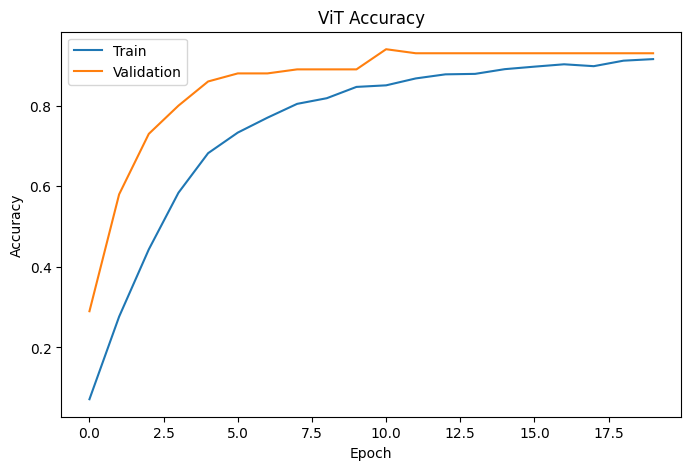

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("ViT Accuracy")

plt.legend()

plt.show()

### Loss Curve

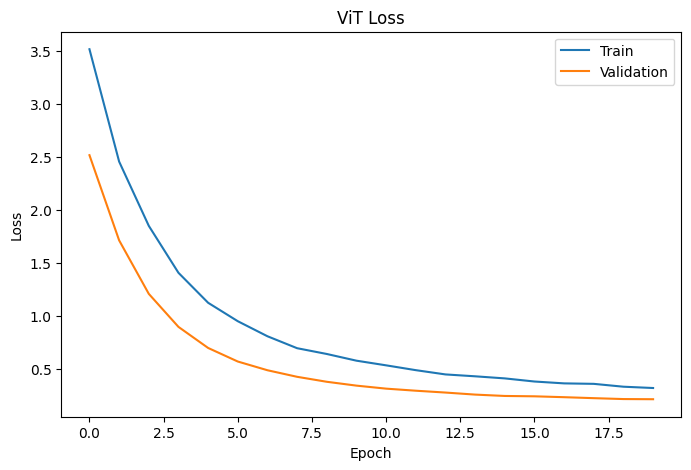

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("ViT Loss")

plt.legend()

plt.show()

### Evaluate Model

In [20]:
test_loss, test_acc = model.evaluate(
    test_ds
)

print(
    "Test Accuracy:",
    test_acc
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.9400 - loss: 0.1643
Test Accuracy: 0.9399999976158142


### Predictions

In [21]:
y_true = []

for images, labels in test_ds:

    y_true.extend(
        labels.numpy()
    )

In [22]:
predictions = model.predict(
    test_ds
)

y_pred = np.argmax(
    predictions,
    axis=1
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 888ms/step


In [23]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(y_true.shape)
print(y_pred.shape)

prediction_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred
})

prediction_df.to_csv("ViT_predictions.csv", index=False)

print("ViT_predictions.csv saved.")

(100,)
(100,)
ViT_predictions.csv saved.


### Confusion Matrix

In [24]:
cm = confusion_matrix(
    y_true,
    y_pred
)

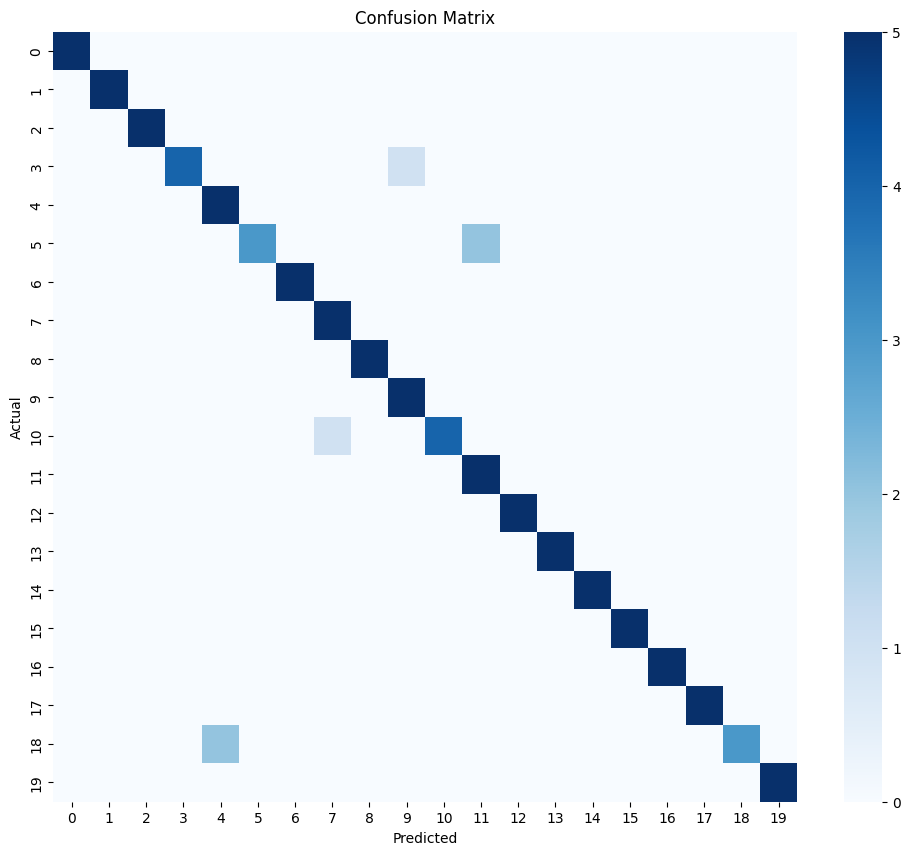

In [25]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

### Classification Report

In [26]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names

    )
)

                         precision    recall  f1-score   support

   ARCIGERA FLOWER MOTH       1.00      1.00      1.00         5
             ATLAS MOTH       1.00      1.00      1.00         5
      BANDED TIGER MOTH       1.00      1.00      1.00         5
BIRD CHERRY ERMINE MOTH       1.00      0.80      0.89         5
          CINNABAR MOTH       0.71      1.00      0.83         5
         CLEARWING MOTH       1.00      0.60      0.75         5
             COMET MOTH       1.00      1.00      1.00         5
       EMPEROR GUM MOTH       0.83      1.00      0.91         5
      GARDEN TIGER MOTH       1.00      1.00      1.00         5
     GIANT LEOPARD MOTH       0.83      1.00      0.91         5
          HERCULES MOTH       1.00      0.80      0.89         5
 HUMMING BIRD HAWK MOTH       0.71      1.00      0.83         5
                IO MOTH       1.00      1.00      1.00         5
              LUNA MOTH       1.00      1.00      1.00         5
 MADAGASCAN SUNSET MOTH 

In [27]:
results = {
    "accuracy": test_acc,
    "loss": test_loss
}

print(results)

{'accuracy': 0.9399999976158142, 'loss': 0.16433586180210114}


In [28]:
model.save(
    "ViT.keras"
)